In [1]:
import nugget
import numpy as np
import importlib
import pickle
import torch
import matplotlib.pyplot as plt
import os
import scipy

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [3]:
spacing = np.linspace(25,200,20)
for string_spacing in spacing:
    print(string_spacing)

25.0
34.21052631578947
43.421052631578945
52.631578947368425
61.8421052631579
71.05263157894737
80.26315789473685
89.47368421052632
98.6842105263158
107.89473684210527
117.10526315789474
126.31578947368422
135.5263157894737
144.73684210526318
153.94736842105263
163.1578947368421
172.3684210526316
181.57894736842107
190.78947368421055
200.0


In [12]:
device = None
lightsabre_surrogate = nugget.surrogates.LightSabre.LightSabre(device=device, use_poisson=False, domain_size=2500, particle_mode = 'track')
light_yield_surrogate = lightsabre_surrogate.light_yield_surrogate
signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(
                                        device=device, 
                                        event_type='signal', 
                                        domain_size=2500, 
                                        E_min=1e2, 
                                        E_max=1e8, 
                                        find_exact_intersection=False, 
                                        random_position_along_ray=True, 
                                        energy_dist='log_uniform',
                                        cylinder_center=torch.tensor([0.0, 0.0, 0.0]),
                                        cylinder_radius=600.0,
                                        cylinder_height=1000.0,
                                        # cos_range=torch.tensor((np.cos(np.pi/2),np.cos(np.pi/2)))
                                        )

In [13]:
importlib.reload(nugget.utils.basic_evaluator)
importlib.reload(nugget.utils.vis_tools)
importlib.reload(nugget.geometries.EvanescentString)
geometry = nugget.geometries.EvanescentString.EvanescentString(
            device=device,
            hex_type='hexagonal',
            domain_size=1600,  # Size of detector domain
            dim=3,  # 3D geometry
            n_strings=1027,  # Initial number of detector strings (ignore)
            points_per_string=20,  # Number of OMs per string
            custom_z_spacing=50, # OM spacing along string
            starting_weight =1000,
            active_weights_mode=True
        )

visualizer = nugget.utils.vis_tools.Visualizer(
    device=device,
    dim=3, 
    domain_size=2500,
    )

evaluator = nugget.utils.basic_evaluator.Evaluator(
    device=device,
    geometry=geometry,
    visualizer=visualizer,
)

In [14]:
# test_signal_events = pickle.load(open('/u/kristiantcho/ptmp/nugget/nugget/examples/res_test/signal_events_30000_r600_50_pl_1.pkl', 'rb'))
test_signal_events = nugget.utils.data_tools.load_signal_events_parquet('/u/kristiantcho/ptmp/nugget/nugget/examples/res_test/signal_events_30000_r600_50_u_1.pt')

In [15]:
importlib.reload(nugget.losses.geometry_penalties)
importlib.reload(nugget.losses.fisher_info)
importlib.reload(nugget.losses.pointsource_fom)
rov_penalty = nugget.losses.geometry_penalties.ROVPenalty(
    device=geometry.device, 
    rov_rec_width=230,  # ROV dimensions
    rov_height=159.9, 
    rov_tri_length=159.9
)

angular_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    device=geometry.device,
    # device="cuda:3",
    resolution_type='angular',
    fisher_info_params=['position','energy', 'direction']
)
# pointsource_fom_loss = nugget.losses.pointsource_fom.FoMLoss(
#     device=geometry.device,
#     fisher_info_params=['position','energy', 'direction']
# )

loss_params ={
    'num_angles': 360,  # Number of angles (divided into 360 degrees) to test for rov
    'num_events':30000,
    'rov_alt_mode': True,  # Whether to use alternative mode for rov penalty (see rov_penalty.py for details)
    'signal_surrogate_func': light_yield_surrogate,
    'signal_event_params': test_signal_events,
    'perfect_efficiency': True,
    'bounding_cylinder_temperature': 0.1,
    'per_effective_area_loss': True,
    'use_irregular_cylinder':True,
    'use_batched_effective_area': True,
    'normalize_fom_by_energy': False,
    # 'fisher_info_params': ['position','energy', 'direction'],
    # 'fisher_info_grad_chunk_size': 7,  # Chunk size for computing gradients of Fisher information (adjust based on memory)
    # 'fisher_info_jacrev_chunk_size': 50000,  # Chunk size for computing Jacobians of Fisher information (adjust based on memory)
    # 'fisher_info_point_chunk_size': 70000,  # Chunk size for processing events when computing Fisher information (adjust based on memory)
    # 'fisher_info_llr_autodiff_mode': 'jvp',  # Method for computing gradients of log-likelihood ratio ('grad' or 'jacrev')
    # 'precomputed_fisher_info_per_string_per_event': torch.load(f'res_test/fisher_info_per_string_per_event_10000_800main_full_hex_600_50_4.pt') 
}

loss_func_dict = {
    'rov_penalty': rov_penalty,
    'angular_resolution_loss': angular_resolution_loss,
    # 'pointsource_fom_loss': pointsource_fom_loss
}

plot_types = [
    'string_xy',
    'string_xy_rov_penalty',
    'angular_resolution_vs_zenith',
    'angular_resolution_vs_energy',
    # 'pointsource_fom_vs_energy',
]

vis_kwargs = {
    'plot_types': plot_types,
    'zoom_range':900,
    'show_resolution_ci':True,
    'rov_penalty_func': rov_penalty,
    'draw_weighted_cylinder': False,
    'ratio_baseline_geometry': 'modified',
    'rov_draw_safe_space_on_violations':False,
    'n_zenith_bins': 10,  # Binning for angular resolution plots
    'n_energy_bins': 10,   # Binning for energy resolution plots
    'resolution_logy': False,  # Whether to use log scale for resolution plots,
    'resolution_stat': 'fom',  # Statistic to plot for resolution ('median' or 'mean')
    # 'min_angular_resolution': 0.00004,  # Minimum angular resolution to display (degrees)
    # 'max_angular_resolution': np.pi*2,  # Maximum angular resolution to display (degrees)
    
}

In [16]:
geom_dicts = {}
loss_param_dicts = {}
focus = 'ang_res'
version = 'r600_50_pl_1'
compare_version = 'r600_50_pl_1'
num_events = 30000
for geom_name in ['default', 'large', 'modified', 'expanded', 'compact']:
    if geom_name == '800main_full_hex':
        for addon_name in ['_rov', '_rov_alt']:
            geom_files = sorted([f for f in os.listdir(f'{geom_name}_{compare_version}_{focus}{addon_name}') if f.startswith('geom_') and f.endswith('.pkl')],
                        key=lambda x: int(x.split('_')[1].split('.')[0]))
            geom_dict = pickle.load(open(f'{geom_name}_{compare_version}_{focus}{addon_name}/{geom_files[-1]}', 'rb'))
            geom_name_full = geom_name + addon_name
            geom_dicts[geom_name_full] = geom_dict
            # IMPORTANT: copy loss_params per-geometry so we don't overwrite the same dict
            loss_param_dicts[geom_name_full] = dict(loss_params)
            loss_param_dicts[geom_name_full]['precomputed_fisher_info_per_string_per_event'] = torch.load(
                f'res_test/fisher_info_per_string_per_event_{num_events}_{geom_name}_{version}.pt'
            )
        continue
    temp_name = '340grid'
    string_xy = np.load(f'../other/{temp_name}_xy.npy')
    highlight_xy = np.load(f'../other/{geom_name}_xy.npy')
    string_weights = np.ones(string_xy.shape[0])*(-1000)
    # Match each highlight point to the closest string (robust to small float differences)
    diffs = string_xy[None, :, :] - highlight_xy[:, None, :]   # (n_highlight, n_strings, 2)
    dists = np.linalg.norm(diffs, axis=2)                      # (n_highlight, n_strings)
    closest_idx = np.argmin(dists, axis=1)
    string_weights[np.unique(closest_idx)] = 1000
    geom_dict = {'string_xy': string_xy, 'string_weights': string_weights}
    # elif geom_name == '600hexagon':
    #     geom_dict = {'n_strings': 70}
    geom_dicts[geom_name] = geom_dict
    # IMPORTANT: copy loss_params per-geometry so we don't overwrite the same dict
    loss_param_dicts[geom_name] = dict(loss_params)
    loss_param_dicts[geom_name]['precomputed_fisher_info_per_string_per_event'] = torch.load(
        f'res_test/fisher_info_per_string_per_event_{num_events}_{temp_name}_{version}.pt'
    )

In [31]:
geom_dicts = {}
loss_param_dicts = {}
for geom_name in ['800main']:
    for extra_addon_name in ['', '_e2_e4', '_e6_e8']:
    # for extra_addon_name in ['', '_z155_z180', '_z70_z110']:
        for addon_name in ['_rov', '_no_rov']:
            geom_files = sorted([f for f in os.listdir(f'{geom_name}_r600_50{extra_addon_name}_1_ang_res{addon_name}') if f.startswith('geom_') and f.endswith('.pkl')],
                        key=lambda x: int(x.split('_')[1].split('.')[0]))
            geom_dict = pickle.load(open(f'{geom_name}_r600_50{extra_addon_name}_1_ang_res{addon_name}/{geom_files[-1]}', 'rb'))
            geom_dicts[geom_name+extra_addon_name+addon_name] = geom_dict
            # IMPORTANT: copy loss_params per-geometry so we don't overwrite the same dict
            loss_param_dicts[geom_name+extra_addon_name+addon_name] = dict(loss_params)
            
            # if addon_name == '_e2_e4' or addon_name == '_e6_e8' or extra_addon_name == '_z155_z180' or extra_addon_name == '_z70_z110':
            #     loss_param_dicts[geom_name+extra_addon_name+addon_name]['signal_event_params'] = pickle.load(
            #         open(f'res_test/signal_events_10000_r600_50{extra_addon_name}_1.pkl', 'rb'))
            #     loss_param_dicts[geom_name+extra_addon_name+addon_name]['precomputed_fisher_info_per_string_per_event'] = torch.load(
            #         f'res_test/fisher_info_per_string_per_event_10000_800main_r600_50{extra_addon_name}_1.pt')  
            # else:

In [ ]:
results = evaluator.evaluate(
    geom_dict=geom_dicts['800main'],
    loss_func_dict=loss_func_dict,
    loss_params_dict=loss_param_dicts['600hexagon'],
    vis_kwargs=vis_kwargs,
    visualize=True,
)

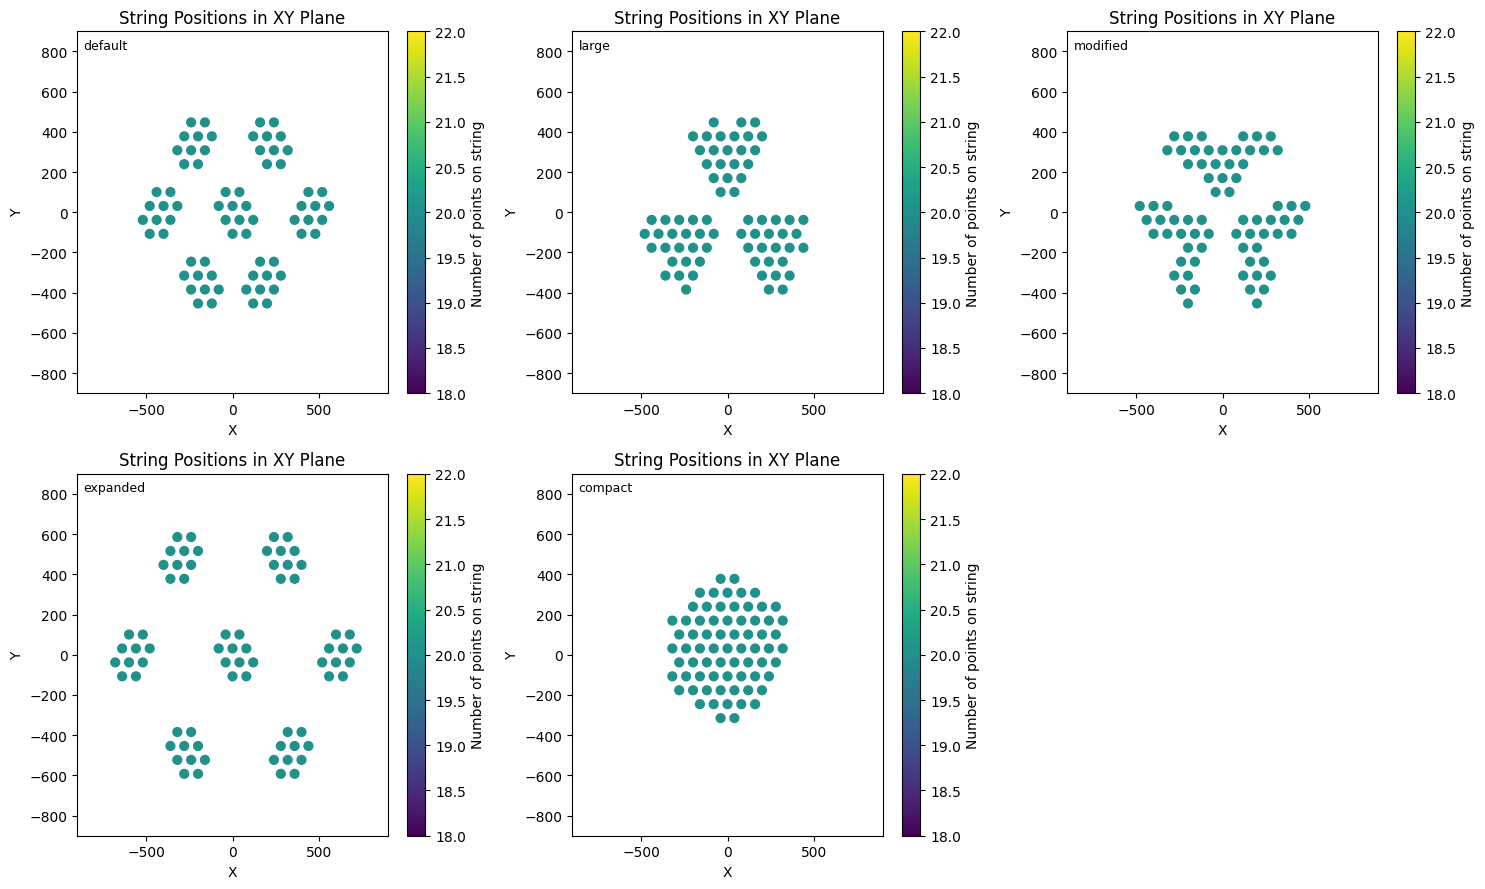

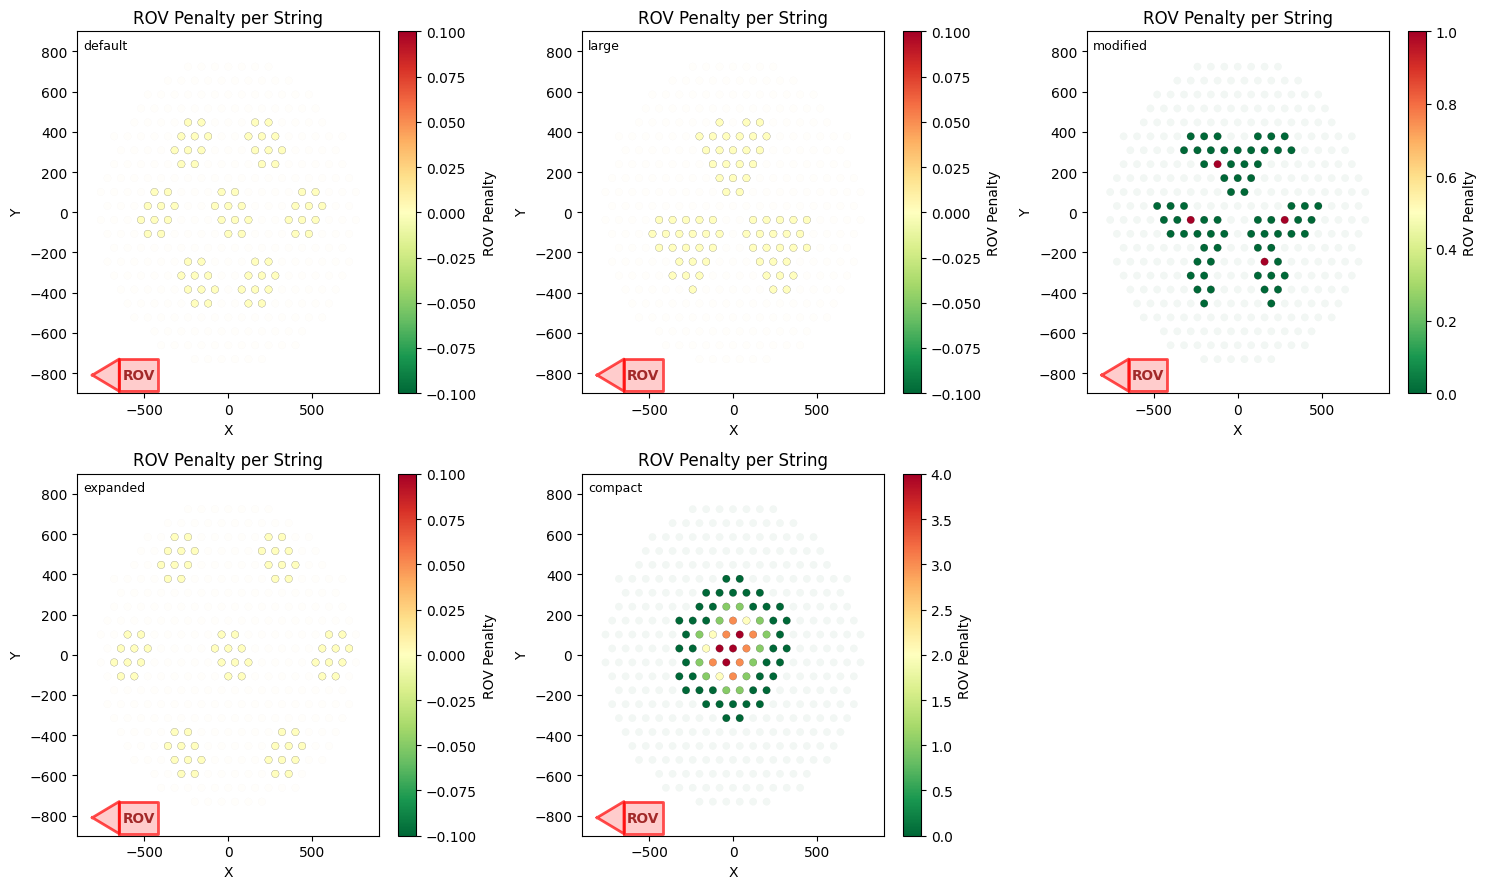

/ptmp/mpp/kristiantcho/nugget/nugget/utils/vis_tools.py:2266: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


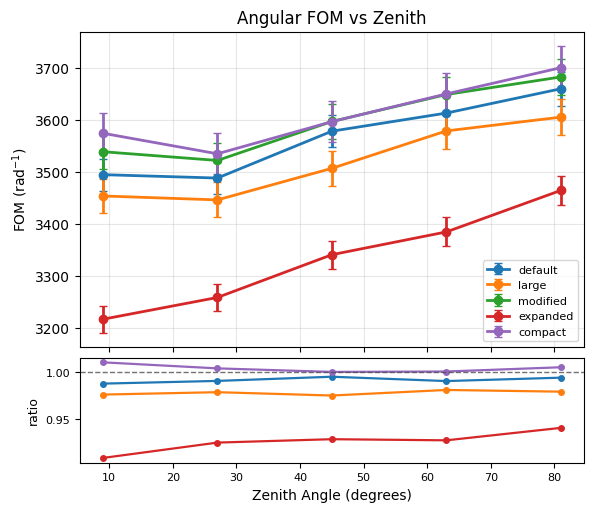

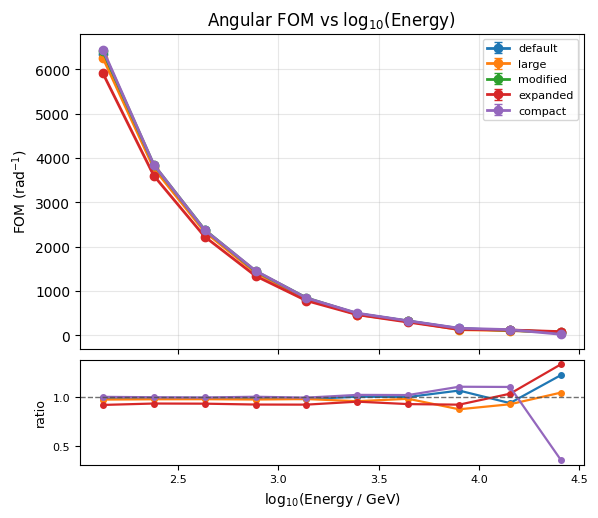

Eval[default] | rov_penalty: 0 | angular_resolution_loss: 0.000125365
Eval[large] | rov_penalty: 0 | angular_resolution_loss: 0.000127098
Eval[modified] | rov_penalty: 0.0117302 | angular_resolution_loss: 0.000124289
Eval[expanded] | rov_penalty: 0 | angular_resolution_loss: 0.000134127
Eval[compact] | rov_penalty: 0.170088 | angular_resolution_loss: 0.000123831


In [17]:
result =evaluator.evaluate_multi(
    geom_dicts=geom_dicts,
    loss_func_dict=loss_func_dict,
    loss_params_dicts=loss_param_dicts,
    vis_kwargs=vis_kwargs,
    visualize=True,
)

In [11]:
# for key in geom_dicts.keys():
for key in ['800main_full_hex_rov',]:
    print(key)

    # calculate distances of each active string from every other string in 2d
    weights = torch.sigmoid(geom_dicts[key]['string_weights'])
    xy = geom_dicts[key]['string_xy']
    active_indices = torch.where(weights > 0.7)[0]
    active_xy = xy[active_indices]

    dists = active_xy.unsqueeze(1) - active_xy.unsqueeze(0)
    dists = torch.norm(dists, dim=-1)

    print(
        'Average distance between 5 nearest neighbors of active strings:',
        torch.topk(dists, k=6, largest=False).values[:, 1:].mean().item()
    )
    print('Mininmum distance between active strings:', dists[dists > 0].min().item())

    # center and average radius using all active points
    center = torch.mean(active_xy, dim=0)
    print('Center of active strings:', center.cpu().numpy())
    avg_radius = torch.norm(active_xy - center, dim=-1).mean().item()
    print('Average radius (all active points):', avg_radius)

    # average radius using only outer-most points (convex hull vertices)
    active_xy_np = active_xy.detach().cpu().numpy()
    center_np = center.detach().cpu().numpy()

    if active_xy_np.shape[0] >= 3:
        try:
            hull = scipy.spatial.ConvexHull(active_xy_np)
            outer_xy_np = active_xy_np[hull.vertices]
        except Exception:
            outer_xy_np = active_xy_np
    else:
        outer_xy_np = active_xy_np

    outer_avg_radius = np.linalg.norm(outer_xy_np - center_np, axis=1).mean()
    print('Average radius (outer-most points):', float(outer_avg_radius))
    

800main_full_hex_rov
Average distance between 5 nearest neighbors of active strings: 145.12110900878906
Mininmum distance between active strings: 44.44441604614258
Center of active strings: [-17.14286   20.894583]
Average radius (all active points): 404.2510681152344
Average radius (outer-most points): 628.6011352539062


mean x position: 1.9323043333292007
mean y position: 4.147034381818771


Text(0, 0.5, 'Y Position (m)')

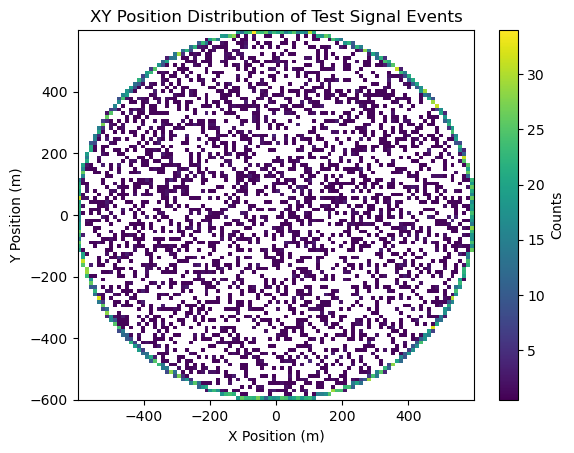

In [8]:
# create a heatmap of the xy positions of the events, make counts 0 white
new_test_signal_events = signal_sampler.sample_events(num_events=10000)
x_positions = [event['position'][0][0].item() for event in new_test_signal_events]
y_positions = [event['position'][0][1].item() for event in new_test_signal_events]

print('mean x position:', np.mean(x_positions))
print('mean y position:', np.mean(y_positions))
cmap = plt.cm.viridis.copy()
cmap.set_under('white')  # values below vmin -> white

plt.hist2d(x_positions, y_positions, bins=100, cmap=cmap, vmin=0.5)
plt.colorbar(label='Counts')
plt.title('XY Position Distribution of Test Signal Events')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')


Using 15 / 15 geometries from res_test/opt_geoms_full_hex_10000_r600_50_4_rov


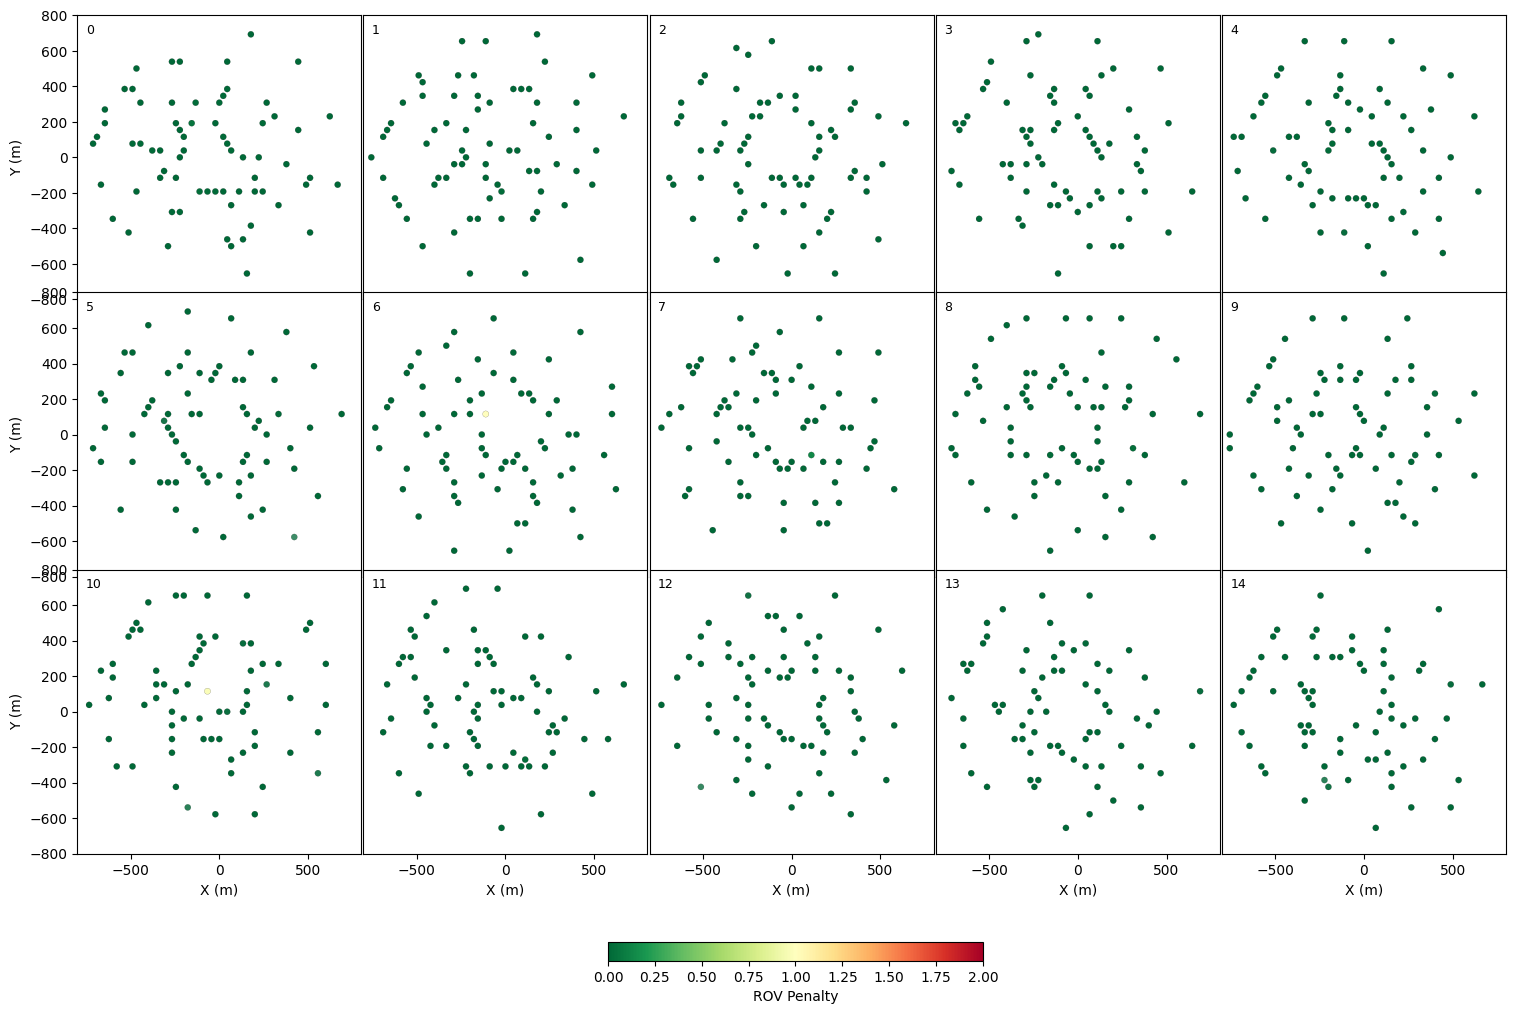

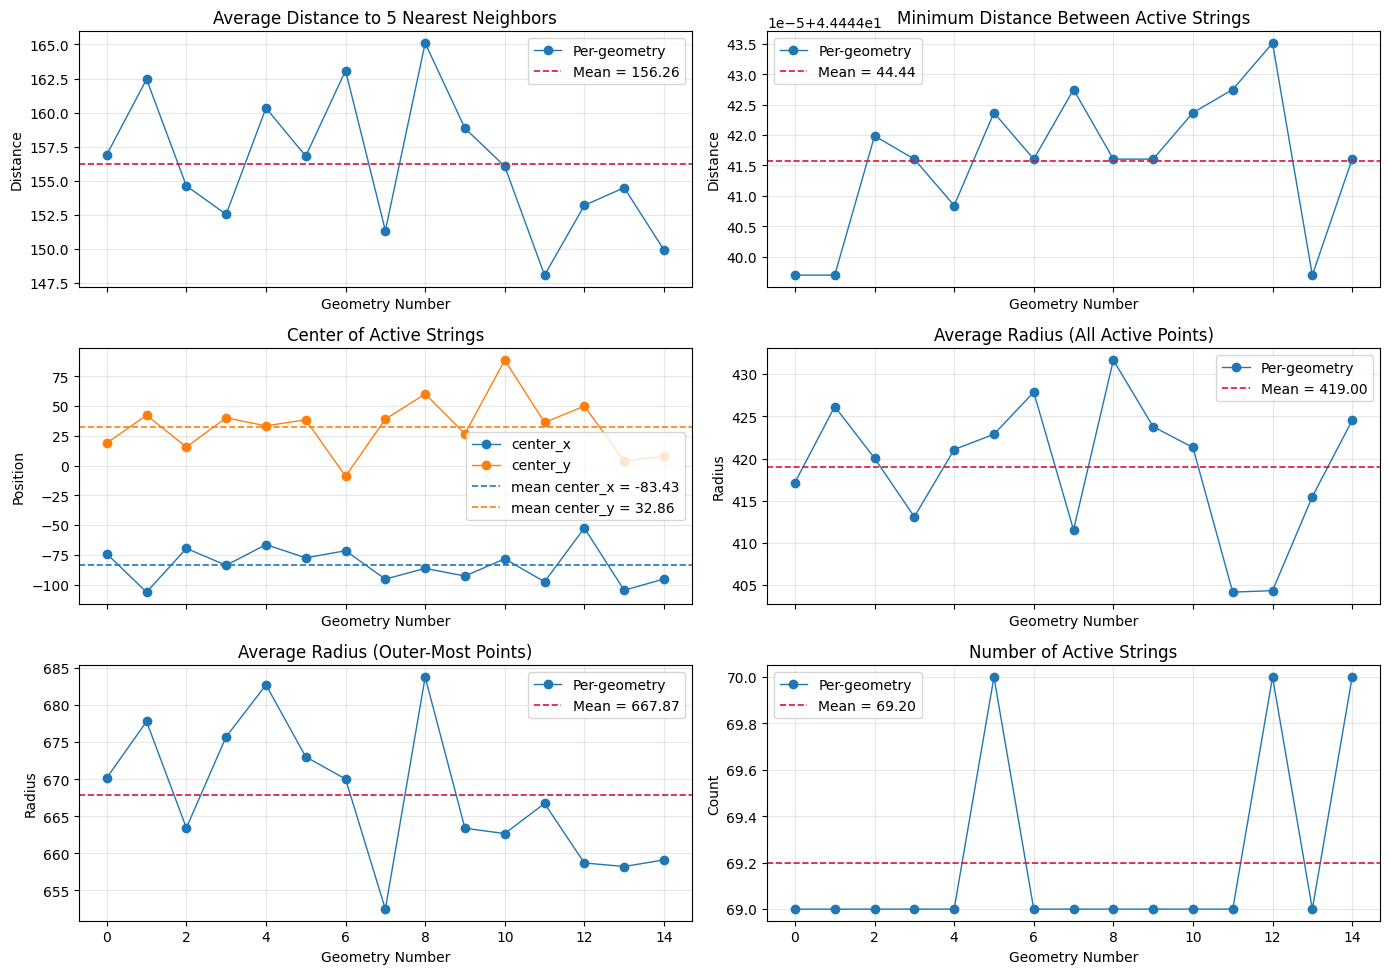

In [ ]:
# Display all geometries from one folder and summarize per-geometry stats
from pathlib import Path
from scipy.spatial import ConvexHull

# Folder containing geom_*.pkl files
geom_folder = Path("./res_test/opt_geoms_full_hex_30000_r600_50_pl_1_rov")
num_angles = 360
num_cols = 5
zoom_range = 800
# Number of geometries to plot/analyze
# Set to None (or <=0) to use all geometries
num_geometries_to_pick = 15

if not geom_folder.exists():
    raise FileNotFoundError(f"Folder not found: {geom_folder}")

# Ensure we have an ROV penalty object
rov_loss = nugget.losses.geometry_penalties.ROVPenalty(
    rov_rec_width=230,
    rov_height=160,
    rov_tri_length=160,
)

# Sort geometries by the numeric suffix in geom_<idx>.pkl
all_geom_paths = sorted(
    [p for p in geom_folder.glob("geom_*.pkl")],
    key=lambda p: int(p.stem.split("_")[1]),
)

if len(all_geom_paths) == 0:
    raise RuntimeError(f"No geom_*.pkl files found in {geom_folder}")

# Randomly subsample geometries if requested
total_geoms = len(all_geom_paths)
if num_geometries_to_pick is None or num_geometries_to_pick <= 0 or num_geometries_to_pick >= total_geoms:
    geom_paths = all_geom_paths
else:
    pick_indices = np.random.choice(total_geoms, size=num_geometries_to_pick, replace=False)
    geom_paths = [all_geom_paths[int(i)] for i in pick_indices]

print(f"Using {len(geom_paths)} / {total_geoms} geometries from {geom_folder}")

# Preload geometry dicts and compute global color scale
geom_records = []
all_rov_penalties = []
for geom_path in geom_paths:
    geom_idx = int(geom_path.stem.split("_")[1])
    geom_dict = pickle.load(open(geom_path, "rb"))

    rov_per_string = (
        rov_loss(geom_dict, num_angles=num_angles, rov_alt_mode=True)["rov_penalty_per_string"]
        * len(geom_dict["string_xy"])
    )
    all_rov_penalties.extend(rov_per_string.detach().cpu().numpy().ravel())

    geom_records.append({
        "idx": geom_idx,
        "path": geom_path,
        "geom_dict": geom_dict,
        "rov_per_string": rov_per_string,
    })

if len(all_rov_penalties) == 0:
    raise RuntimeError("No ROV penalty values were computed")

vmin = float(np.min(all_rov_penalties))
vmax = float(np.max(all_rov_penalties))

# --- Figure 1: geometry grid ---
num_geoms = len(geom_records)
num_rows = int(np.ceil(num_geoms / num_cols))

fig, axes = plt.subplots(
    nrows=num_rows,
    ncols=num_cols,
    figsize=(num_cols * 3, num_rows * 3.2),
    squeeze=False,
    sharex=True,
    sharey=True,
)

scatter = None
for plot_i in range(num_rows * num_cols):
    row_idx = plot_i // num_cols
    col_idx = plot_i % num_cols
    ax = axes[row_idx, col_idx]

    if plot_i >= num_geoms:
        ax.set_visible(False)
        continue

    record = geom_records[plot_i]
    geom_dict = record["geom_dict"]
    string_xy = geom_dict["string_xy"].detach().cpu().numpy()

    if "string_weights" in geom_dict:
        string_weights = geom_dict["string_weights"].detach().cpu().numpy()
        sig_weights = 1.0 / (1.0 + np.exp(-string_weights))
    else:
        sig_weights = np.ones(string_xy.shape[0], dtype=float)

    scatter = ax.scatter(
        string_xy[:, 0][sig_weights > 0.7],
        string_xy[:, 1][sig_weights > 0.7],
        c=record["rov_per_string"][sig_weights > 0.7].detach().cpu().numpy(),
        rasterized=True,
        alpha=sig_weights[sig_weights > 0.7],
        s=20,
        cmap="RdYlGn_r",
        vmin=vmin,
        vmax=vmax,
        edgecolors="k",
        linewidths=0.1,
    )
    ax.set_xlim([-zoom_range, zoom_range])
    ax.set_ylim([-zoom_range, zoom_range])
    ax.set_aspect("equal")

    # Show axis labels only on the left column and bottom row
    is_left_col = col_idx == 0
    is_bottom_row = row_idx == (num_rows - 1)
    ax.tick_params(
        axis="both",
        which="both",
        labelleft=is_left_col,
        labelbottom=is_bottom_row,
        left=is_left_col,
        bottom=is_bottom_row,
    )
    if is_left_col:
        ax.set_ylabel("Y (m)")
    if is_bottom_row:
        ax.set_xlabel("X (m)")

    # Put geometry number inside the subplot corner
    ax.text(
        0.03,
        0.97,
        f"{record['idx']}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.7, "pad": 1.5},
    )

# Reserve bottom space first, then draw colorbar in a dedicated axis to avoid overlap
fig.tight_layout(rect=[0.0, 0.08, 1.0, 1.0], pad=0.15)
if scatter is not None:
    cax = fig.add_axes([0.40, 0.01, 0.25, 0.02])
    cbar = fig.colorbar(scatter, cax=cax, orientation="horizontal")
    cbar.set_label("ROV Penalty")

plt.show()

# --- Figure 2: per-geometry stats (same calculations as test_evaluation) ---
stats_idx = []
active_string_counts = []
avg_5nn = []
min_dist = []
center_x = []
center_y = []
avg_radius_all = []
avg_radius_outer = []

for record in geom_records:
    geom_dict = record["geom_dict"]

    xy = geom_dict["string_xy"]
    if "string_weights" in geom_dict:
        weights = torch.sigmoid(geom_dict["string_weights"])
        active_indices = torch.where(weights > 0.7)[0]
    else:
        active_indices = torch.arange(xy.shape[0], device=xy.device)

    active_xy = xy[active_indices]
    active_string_counts.append(int(active_xy.shape[0]))

    if active_xy.shape[0] < 2:
        stats_idx.append(record["idx"])
        avg_5nn.append(np.nan)
        min_dist.append(np.nan)
        center_x.append(np.nan)
        center_y.append(np.nan)
        avg_radius_all.append(np.nan)
        avg_radius_outer.append(np.nan)
        continue

    dists = active_xy.unsqueeze(1) - active_xy.unsqueeze(0)
    dists = torch.norm(dists, dim=-1)

    k_neighbors = min(6, active_xy.shape[0])
    nearest = torch.topk(dists, k=k_neighbors, largest=False).values[:, 1:]

    center = torch.mean(active_xy, dim=0)
    avg_radius = torch.norm(active_xy - center, dim=-1).mean().item()

    active_xy_np = active_xy.detach().cpu().numpy()
    center_np = center.detach().cpu().numpy()

    if active_xy_np.shape[0] >= 3:
        try:
            hull = ConvexHull(active_xy_np)
            outer_xy_np = active_xy_np[hull.vertices]
        except Exception:
            outer_xy_np = active_xy_np
    else:
        outer_xy_np = active_xy_np

    outer_avg_radius = np.linalg.norm(outer_xy_np - center_np, axis=1).mean()

    nonzero_d = dists[dists > 0]

    stats_idx.append(record["idx"])
    avg_5nn.append(nearest.mean().item() if nearest.numel() > 0 else np.nan)
    min_dist.append(nonzero_d.min().item() if nonzero_d.numel() > 0 else np.nan)
    center_x.append(float(center_np[0]))
    center_y.append(float(center_np[1]))
    avg_radius_all.append(float(avg_radius))
    avg_radius_outer.append(float(outer_avg_radius))

stats_idx = np.array(stats_idx)
order = np.argsort(stats_idx)
stats_idx = stats_idx[order]
active_string_counts = np.array(active_string_counts)[order]
avg_5nn = np.array(avg_5nn)[order]
min_dist = np.array(min_dist)[order]
center_x = np.array(center_x)[order]
center_y = np.array(center_y)[order]
avg_radius_all = np.array(avg_radius_all)[order]
avg_radius_outer = np.array(avg_radius_outer)[order]

# Means for horizontal reference lines
active_string_count_mean = float(np.nanmean(active_string_counts))
avg_5nn_mean = float(np.nanmean(avg_5nn))
min_dist_mean = float(np.nanmean(min_dist))
center_x_mean = float(np.nanmean(center_x))
center_y_mean = float(np.nanmean(center_y))
avg_radius_all_mean = float(np.nanmean(avg_radius_all))
avg_radius_outer_mean = float(np.nanmean(avg_radius_outer))

fig2, axes2 = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes2 = axes2.ravel()

axes2[0].plot(stats_idx, avg_5nn, marker="o", linewidth=1, label="Per-geometry")
axes2[0].axhline(avg_5nn_mean, color="crimson", linestyle="--", linewidth=1.2, label=f"Mean = {avg_5nn_mean:.2f}")
axes2[0].set_title("Average Distance to 5 Nearest Neighbors")
axes2[0].set_ylabel("Distance")
axes2[0].grid(alpha=0.3)
axes2[0].legend()

axes2[1].plot(stats_idx, min_dist, marker="o", linewidth=1, label="Per-geometry")
axes2[1].axhline(min_dist_mean, color="crimson", linestyle="--", linewidth=1.2, label=f"Mean = {min_dist_mean:.2f}")
axes2[1].set_title("Minimum Distance Between Active Strings")
axes2[1].set_ylabel("Distance")
axes2[1].grid(alpha=0.3)
axes2[1].legend()

axes2[2].plot(stats_idx, center_x, marker="o", linewidth=1, label="center_x")
axes2[2].plot(stats_idx, center_y, marker="o", linewidth=1, label="center_y")
axes2[2].axhline(center_x_mean, color="tab:blue", linestyle="--", linewidth=1.2, label=f"mean center_x = {center_x_mean:.2f}")
axes2[2].axhline(center_y_mean, color="tab:orange", linestyle="--", linewidth=1.2, label=f"mean center_y = {center_y_mean:.2f}")
axes2[2].set_title("Center of Active Strings")
axes2[2].set_ylabel("Position")
axes2[2].legend()
axes2[2].grid(alpha=0.3)

axes2[3].plot(stats_idx, avg_radius_all, marker="o", linewidth=1, label="Per-geometry")
axes2[3].axhline(avg_radius_all_mean, color="crimson", linestyle="--", linewidth=1.2, label=f"Mean = {avg_radius_all_mean:.2f}")
axes2[3].set_title("Average Radius (All Active Points)")
axes2[3].set_ylabel("Radius")
axes2[3].grid(alpha=0.3)
axes2[3].legend()

axes2[4].plot(stats_idx, avg_radius_outer, marker="o", linewidth=1, label="Per-geometry")
axes2[4].axhline(avg_radius_outer_mean, color="crimson", linestyle="--", linewidth=1.2, label=f"Mean = {avg_radius_outer_mean:.2f}")
axes2[4].set_title("Average Radius (Outer-Most Points)")
axes2[4].set_xlabel("Geometry Number")
axes2[4].set_ylabel("Radius")
axes2[4].grid(alpha=0.3)
axes2[4].legend()

axes2[5].plot(stats_idx, active_string_counts, marker="o", linewidth=1, label="Per-geometry")
axes2[5].axhline(active_string_count_mean, color="crimson", linestyle="--", linewidth=1.2, label=f"Mean = {active_string_count_mean:.2f}")
axes2[5].set_title("Number of Active Strings")
axes2[5].set_ylabel("Count")
axes2[5].grid(alpha=0.3)
axes2[5].legend()

for ax in axes2:
    ax.set_xlabel("Geometry Number")

fig2.tight_layout()
plt.show()

In [ ]:
num_events = 10000
# version = 'r600_50_1_c'
version = 'r600_50_4'

lightsabre_surrogate = nugget.surrogates.LightSabre.LightSabre(use_poisson=True, domain_size=1600, particle_mode = 'track')
light_yield_surrogate = lightsabre_surrogate.light_yield_surrogate

signal_events = pickle.load(open(f'/u/kristiantcho/ptmp/nugget/nugget/examples/res_test/signal_events_{num_events}_{version}.pkl', 'rb'))

angular_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    resolution_type='angular',
    fisher_info_params=['position','energy', 'direction']
)
energy_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    resolution_type='energy',
    fisher_info_params=['position','energy', 'direction']
)

loss_params = {
'signal_surrogate_func': light_yield_surrogate,
'perfect_efficiency': False,
'skip_zero_response': True,
# 'fisher_info_llr_net': llr_net,
'use_relative_energy': True,
'num_events':10000,
'signal_event_params': signal_events,

# 'precomputed_fisher_info_per_string_per_event': torch.load('/u/kristiantcho/ptmp/nugget/nugget/examples/res_test_fisher_info_per_string_per_event_100_base_geom_2.pt')
}
energy_loss_dicts = []
angular_loss_dicts = []
for string_spacing in np.linspace(25,200,20):
    geometry = nugget.geometries.SpaceString.SpaceString(
            hex_type='hexagonal',
            domain_size=2500,  # Size of detector domain
            # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),  # Use GPU if available
            dim=3,  # 3D geometry
            n_strings=61,  # Initial number of detector strings
            points_per_string=20,  # Number of PMTs/sensors per string
            # starting_weight=-0.5,  # Initial weight for each string (controls visibility)
            # custom_string_spacing=0.09  # Custom spacing between strings
            starting_spacing=string_spacing,
            starting_z_spacing=50
        )
    geom_dict = geometry.initialize_points()
    try:
        precomputed_fisher_info = torch.load(f'res_test/space_test/fisher_info_per_string_per_event_{num_events}_{int(string_spacing)}_{version}.pt')
        loss_params['precomputed_fisher_info_per_string_per_event'] = precomputed_fisher_info
    except FileNotFoundError:
        continue

    energy_loss_dict = energy_resolution_loss(geom_dict, **loss_params)
    angular_loss_dict = angular_resolution_loss(geom_dict, **loss_params)
    energy_loss_dicts.append(energy_loss_dict)
    angular_loss_dicts.append(angular_loss_dict)


/ptmp/mpp/kristiantcho/nugget/nugget/losses/fisher_info.py:856: UserWarning: Use of index_put_ on expanded tensors is deprecated. Please clone() the tensor before performing this operation. This also applies to advanced indexing e.g. tensor[indices] = tensor (Triggered internally at /pytorch/aten/src/ATen/native/TensorAdvancedIndexing.cpp:967.)
  ref[parallel_mask] = torch.tensor([1.0, 0.0, 0.0], dtype=dtype, device=device)


/tmp/ipykernel_2095131/1268237430.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  energy_foms = np.array([np.median(np.array(loss_dict['resolution_per_event'])) for loss_dict in energy_loss_dicts])


Text(0, 0.5, 'Mean (relative) Energy Resolution')

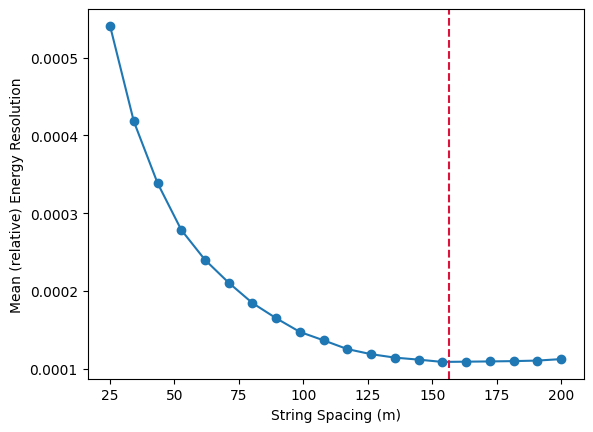

In [13]:

energy_foms = np.array([np.median(np.array(loss_dict['resolution_per_event'])) for loss_dict in energy_loss_dicts])
spacings = np.linspace(25,200,20)[:len(energy_foms)]
plt.plot(spacings, energy_foms, marker='o')
#plot bands for 2sigma confidence interval of the per-event resolutions
energy_stds = []
# for loss_dict in energy_loss_dicts:
#     resolutions = np.array(loss_dict['resolution_per_event'])
#     mean = np.mean(resolutions)
#     std = np.std(resolutions)
#     energy_stds.append(std)
# energy_stds = np.array(energy_stds)
# plt.fill_between(spacings, np.clip(energy_foms - 2*energy_stds, a_min=0, a_max=None), energy_foms + 2*energy_stds, color='blue', alpha=0.2)
f = scipy.interpolate.interp1d(spacings, energy_foms, kind='cubic')
# Create a finer spacing array for interpolation
fine_spacings = np.linspace(spacings.min(), spacings.max(), 1000)
fine_energy_foms = f(fine_spacings)

spacing_min = fine_spacings[np.argmin(fine_energy_foms)]
plt.axvline(spacing_min, color='crimson', linestyle='--', label=f'Min Energy Res at {spacing_min:.1f} m')
plt.xlabel('String Spacing (m)')
# plt.ylabel('Mean Angular Resolution (degrees)')
plt.ylabel('Mean (relative) Energy Resolution')

/tmp/ipykernel_2095131/466582374.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  angular_foms = np.array([np.median(np.array(loss_dict['resolution_per_event'])) for loss_dict in angular_loss_dicts])*180/np.pi


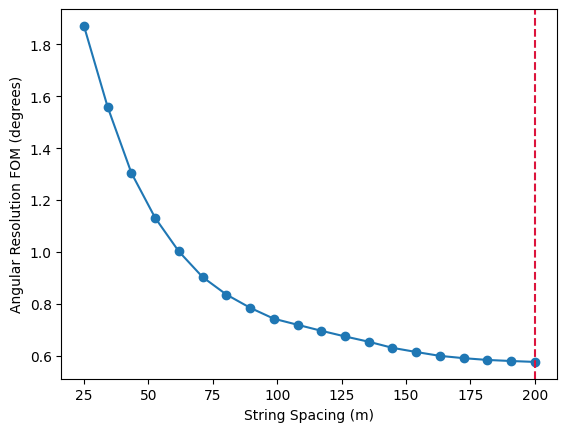

In [ ]:
# angular_foms = np.array([np.median(np.array(loss_dict['resolution_per_event'])) for loss_dict in angular_loss_dicts])*180/np.pi
angular_foms = np.array([loss_dict['angular_resolution_loss'] for loss_dict in angular_loss_dicts])*180/np.pi
spacings = np.linspace(25,200,20)[:len(angular_foms)]
plt.plot(spacings, angular_foms, marker='o')
plt.xlabel('String Spacing (m)')
plt.ylabel('Angular Resolution FOM (degrees)')
# plt.yscale('log')
#interpolate the angular_foms to find the string spacing that achieves minimum angular resolution

f = scipy.interpolate.interp1d(spacings, angular_foms, kind='cubic')
# Create a finer spacing array for interpolation
fine_spacings = np.linspace(spacings.min(), spacings.max(), 1000)
fine_angular_foms = f(fine_spacings)

spacing_min = fine_spacings[np.argmin(fine_angular_foms)]
plt.axvline(spacing_min, color='crimson', linestyle='--', label=f'Min Angular Res at {spacing_min:.1f} m')

In [9]:
version = 'r600_50_pl_1'
# number of energy bins (log-spaced)
n_bins = 1
num_events = 30000
# signal_events = pickle.load(open(f'/u/kristiantcho/ptmp/nugget/nugget/examples/res_test/signal_events_{num_events}_{version}.pkl', 'rb'))
signal_events = nugget.utils.data_tools.load_signal_events_parquet(f'/u/kristiantcho/ptmp/nugget/nugget/examples/res_test/signal_events_{num_events}_{version}.pt')
# extract event energies from signal_events (handles tensors or scalars)
energies = np.array([float(np.asarray(evt['energy']).ravel()[0]) if hasattr(evt['energy'], 'numel') or hasattr(evt['energy'], 'shape') else float(evt['energy']) for evt in signal_events])
pos_mask = energies > 0
if not np.any(pos_mask):
    raise RuntimeError('No positive event energies available for binning')
emin = energies[pos_mask].min()
emax = energies.max()
bin_edges = np.logspace(np.log10(emin), np.log10(emax), n_bins + 1)
# spacings to evaluate (must match precomputed files naming)
spacings = np.linspace(25, 200, 20)
# container: (n_bins, n_spacings) to store scalar FOM (median angular resolution in degrees)
fom_per_bin = np.full((n_bins, len(spacings)), np.nan)
med_per_bin = np.full((n_bins, len(spacings)), np.nan)
# optional zenith split: upgoing vs horizontal-like tracks
split_by_zenith = False
zenith_split = np.pi / 2
fom_per_bin_upgoing = np.full((n_bins, len(spacings)), np.nan)
fom_per_bin_horizontal = np.full((n_bins, len(spacings)), np.nan)

loss_params = {
# 'signal_surrogate_func': light_yield_surrogate,
'perfect_efficiency': False,
'skip_zero_response': True,
# 'fisher_info_llr_net': llr_net,
'use_relative_energy': True,
'num_events':num_events,
'signal_event_params': signal_events,
}

angular_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    resolution_type='angular',
    fisher_info_params=['position','energy', 'direction']
)
energy_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    resolution_type='energy',
    fisher_info_params=['position','energy', 'direction']
)
for i, spacing in enumerate(spacings):
    # build geometry for this spacing (same as used to precompute fisher info)
    geometry = nugget.geometries.SpaceString.SpaceString(hex_type='hexagonal', domain_size=2500, dim=3, n_strings=61, points_per_string=20, starting_spacing=spacing, starting_z_spacing=50)
    geom_dict = geometry.initialize_points()
    # try to load precomputed fisher info matching this spacing
    fname = f'res_test/space_test/fisher_info_per_string_per_event_{num_events}_{int(spacing)}_{version}.pt'
    try:
        precomp = torch.load(fname)
    except FileNotFoundError:
        # skip if precomputed file missing
        continue
    # If precomp is a dict with the tensor under a key, try to find it
    if isinstance(precomp, dict):
        # common keys to try
        for k in ['precomputed_fisher_info_per_string_per_event', 'fisher_info', 'data']:
            if k in precomp:
                precomp_t = precomp[k]
                break
        else:
            # pick first tensor-like value
            vals = [v for v in precomp.values() if isinstance(v, torch.Tensor) or hasattr(v, 'shape')]
            precomp_t = vals[0] if len(vals) > 0 else precomp
    else:
        precomp_t = precomp
    # ensure tensor
    if not isinstance(precomp_t, torch.Tensor):
        try:
            precomp_t = torch.tensor(precomp_t)
        except Exception:
            # cannot convert – skip
            continue
    # locate event axis (the axis whose length equals number of events)
    ev_axis = None
    for ax in range(precomp_t.ndim):
        if precomp_t.shape[ax] == len(energies):
            ev_axis = ax
            break
    if ev_axis is None:
        # fallback: assume axis 1 is events (per_string x per_event naming)
        ev_axis = 1 if precomp_t.ndim > 1 else 0
    # for each energy bin, select events and compute angular-resolution loss using the binned precomputed info
    for b in range(n_bins):
        if b < n_bins - 1:
            mask = (energies >= bin_edges[b]) & (energies < bin_edges[b + 1])
        else:
            mask = (energies >= bin_edges[b]) & (energies <= bin_edges[b + 1])
        idxs = np.where(mask)[0]
        if len(idxs) == 0:
            continue
        idxs_t = torch.tensor(idxs, dtype=torch.long)
        # index-select along event axis to get binned precomputed fisher info
        pre_binned = torch.index_select(precomp_t, ev_axis, idxs_t)
        # Prepare loss_params copy and set binned precomputed info and corresponding events
        local_loss_params = dict(loss_params)
        local_loss_params['precomputed_fisher_info_per_string_per_event'] = pre_binned
        local_loss_params['num_events'] = int(len(idxs))
        # subset signal_event_params if present
        try:
            local_loss_params['signal_event_params'] = [signal_events[int(j)] for j in idxs]
        except Exception:
            pass
        # compute angular resolution loss for this bin and spacing
        loss_out = angular_resolution_loss(geom_dict, **local_loss_params)
        if 'angular_resolution_loss' in loss_out:
            fom_per_bin[b, i] = float(loss_out['angular_resolution_loss']) * 180.0 / np.pi
        else:
            fom_per_bin[b, i] = np.nan

        if split_by_zenith:
            event_zeniths = np.array([
                float(np.asarray(signal_events[int(j)]['zenith']).ravel()[0])
                for j in idxs
            ])
            upgoing_idxs = idxs[event_zeniths >= zenith_split]
            horizontal_idxs = idxs[event_zeniths < zenith_split]

            for subset_idxs, target in [
                (upgoing_idxs, fom_per_bin_upgoing),
                (horizontal_idxs, fom_per_bin_horizontal),
            ]:
                if len(subset_idxs) == 0:
                    continue
                subset_t = torch.tensor(subset_idxs, dtype=torch.long)
                subset_binned = torch.index_select(precomp_t, ev_axis, subset_t)
                subset_loss_params = dict(local_loss_params)
                subset_loss_params['precomputed_fisher_info_per_string_per_event'] = subset_binned
                subset_loss_params['num_events'] = int(len(subset_idxs))
                try:
                    subset_loss_params['signal_event_params'] = [signal_events[int(j)] for j in subset_idxs]
                except Exception:
                    pass
                subset_out = angular_resolution_loss(geom_dict, **subset_loss_params)
                if 'angular_resolution_loss' in subset_out:
                    target[b, i] = float(subset_out['angular_resolution_loss']) * 180.0 / np.pi

# Plot results: colorbar for energy bins and dashed vertical minima lines


/ptmp/mpp/kristiantcho/nugget/nugget/losses/fisher_info.py:856: UserWarning: Use of index_put_ on expanded tensors is deprecated. Please clone() the tensor before performing this operation. This also applies to advanced indexing e.g. tensor[indices] = tensor (Triggered internally at /pytorch/aten/src/ATen/native/TensorAdvancedIndexing.cpp:967.)
  ref[parallel_mask] = torch.tensor([1.0, 0.0, 0.0], dtype=dtype, device=device)


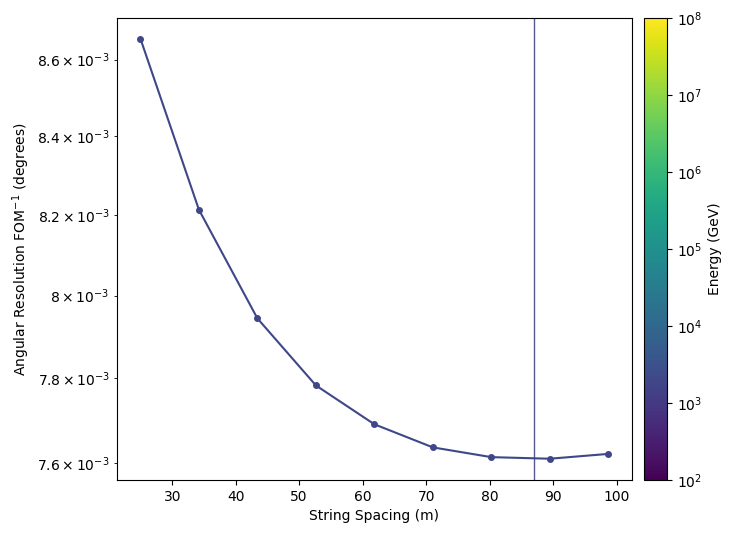

In [10]:
plt.figure(figsize=(8, 6))
ax = plt.gca()
# compute geometric bin centers for log-scaled energy coloring
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
log_centers = np.log10(bin_centers)
# force colorbar to span from 10^2 to 10^8 GeV with full color gradient
norm = plt.Normalize(2, 8)
cmap = plt.cm.viridis
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
# give the mappable a real array so colorbar can infer scale
mappable.set_array(log_centers)
colors = mappable.to_rgba(log_centers)

use_split_by_zenith = bool(globals().get('split_by_zenith', False))
if use_split_by_zenith:
    track_series = [
        ('upgoing', fom_per_bin_upgoing, '-'),
        ('horizontal', fom_per_bin_horizontal, '--'),
    ]
else:
    track_series = [
        ('all', fom_per_bin, '-'),
    ]

for b in range(n_bins):
    for track_name, series_matrix, linestyle in track_series:
        series = series_matrix[b]
        valid = np.isfinite(series)
        if not np.any(valid):
            continue

        ax.plot(
            spacings[valid],
            series[valid],
            marker='o',
            color=colors[b],
            markersize=4,
            linestyle=linestyle,
        )

        if np.count_nonzero(valid) >= 2:
            xvals = spacings[valid]
            yvals = series[valid]
            interp_kind = 'cubic' if np.count_nonzero(valid) >= 4 else 'linear'
            f = scipy.interpolate.interp1d(xvals, yvals, kind=interp_kind)
            fine_spacings = np.linspace(xvals.min(), xvals.max(), 1000)
            fine_vals = f(fine_spacings)
            spacing_min = fine_spacings[np.argmin(fine_vals)]
            ax.axvline(spacing_min, color=colors[b], linestyle=linestyle, linewidth=1.0, alpha=0.9)

# colorbar: show energies (labels in scientific notation). attach to the axes
cbar = plt.colorbar(mappable, ax=ax, pad=0.02)
ax.set_yscale('log')
# force fixed ticks from 10^2 to 10^8 GeV
ticks = np.arange(2, 9)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f'$10^{{{int(t)}}}$' for t in ticks])
cbar.set_label('Energy (GeV)')
ax.set_xlabel('String Spacing (m)')
# ax.set_ylabel(r'Angular Resolution (degrees)')
ax.set_ylabel(r'Angular Resolution FOM$^{-1}$ (degrees)')
# ax.grid(True)
plt.show()

Text(0, 0.5, 'Y (m)')

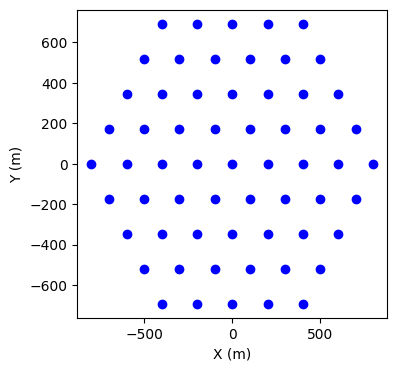

In [10]:
fig = plt.figure(figsize=(4, 4))
plt.scatter(geom_dict['string_xy'][:, 0].cpu(), geom_dict['string_xy'][:, 1].cpu(), c='blue', label='All Strings')
# plt.ylim(-850, 850)
# plt.xlim(-850, 850)
plt.xlabel('X (m)')
plt.ylabel('Y (m)')